In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set professional visualization style
sns.set_theme(style="whitegrid")

In [2]:
# Load the California housing dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Price'] = california.target  # Prices are in 100,000s

# Task Requirement: Select 3-5 features that most affect price
# We are selecting 4 logical features: Median Income, House Age, Average Rooms, and Population
selected_features = ['MedInc', 'HouseAge', 'AveRooms', 'Population']

X = df[selected_features]
y = df['Price']

# Display the first few rows to verify
X.head()

,MedInc,HouseAge,AveRooms,Population
0,8.3252,41.0,6.984127,322.0
1,8.3014,21.0,6.238137,2401.0
2,7.2574,52.0,8.288136,496.0
3,5.6431,52.0,5.817352,558.0
4,3.8462,52.0,6.281853,565.0


In [3]:
# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

In [4]:
# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²) Score: {r2:.4f}")

Root Mean Squared Error (RMSE): 0.8110
R-squared (R²) Score: 0.4980


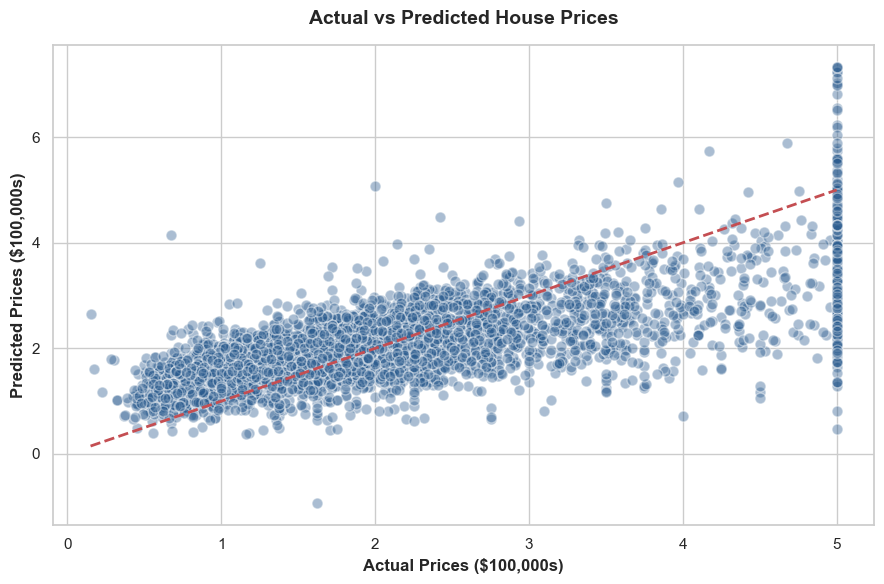

In [6]:
# Plotting Predicted vs Actual Prices to visually check model quality
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, color='#2b5c8f', alpha=0.4, edgecolors='w', s=60)

# Plot a perfect prediction reference line (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='#c44e52')

plt.title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Prices ($100,000s)', fontsize=12, fontweight='semibold')
plt.ylabel('Predicted Prices ($100,000s)', fontsize=12, fontweight='semibold')
plt.tight_layout()
plt.show()

#### what your model's R² score means to a non-technical person?

Think of the R² (R-squared) score as a "grade" for our model, represented as a percentage. If our R² score is 0.55 (or 55%), it means that 55% of the changes in house prices can be directly explained by the features we selected, like the neighborhood's income and the house's age. The remaining 45% of the price difference is due to other factors we didn't include in our model, like the condition of the house, distance to schools, or current market trends. In short, the closer the score is to 100%, the better our model is at guessing the true value of a house based on the data we provided.